In [38]:
!pip install yfinance scikit-learn ta


In [39]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

import ta

plt.style.use("seaborn-v0_8")


In [40]:
symbol = "^NSEI"   # Change if needed

start = "2012-01-01"

df = yf.download(symbol, start=start)

print("Rows:", len(df))

df.head()



/tmp/ipython-input-2011539621.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start)
[*********************100%***********************]  1 of 1 completed


Rows: 3469


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2012-01-03,4765.299805,4773.100098,4675.799805,4675.799805,0
2012-01-04,4749.649902,4782.850098,4728.850098,4774.950195,0
2012-01-05,4749.950195,4779.799805,4730.149902,4749.000000,0
2012-01-06,4754.100098,4794.899902,4686.850098,4724.149902,0
2012-01-09,4742.799805,4758.700195,4695.450195,4747.549805,0


In [41]:
# Make Close 1D
close = df["Close"].squeeze()


# Returns
df["Return"] = close.pct_change()

# Volatility
df["Vol"] = df["Return"].rolling(20).std()

# RSI
df["RSI"] = ta.momentum.RSIIndicator(close).rsi()

# MACD
macd = ta.trend.MACD(close)
df["MACD"] = macd.macd()

# Moving Averages
df["MA20"] = close.rolling(20).mean()
df["MA50"] = close.rolling(50).mean()

df["MA_Diff"] = df["MA20"] - df["MA50"]

# Clean
df = df.dropna()

df.head()



Price,Close,High,Low,Open,Volume,Return,Vol,RSI,MACD,MA20,MA50,MA_Diff
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI,,,,,,,
Date,,,,,,,,,,,,
2012-03-15,5380.500000,5462.500000,5362.299805,5462.500000,0,-0.015264,0.013468,53.495911,33.438095,5403.725000,5208.555986,195.169014
2012-03-16,5317.899902,5445.649902,5305.000000,5380.350098,0,-0.011635,0.012676,49.011822,26.799613,5393.022485,5219.607988,173.414497
2012-03-19,5257.049805,5340.700195,5238.549805,5337.350098,0,-0.011443,0.012854,45.058172,16.438975,5379.777466,5229.755986,150.021479
2012-03-20,5274.850098,5297.350098,5233.250000,5257.149902,0,0.003386,0.012713,46.419781,9.554294,5365.304980,5240.253984,125.050996
2012-03-21,5364.950195,5372.350098,5256.000000,5267.200195,0,0.017081,0.013273,52.796616,11.238905,5353.194995,5252.470986,100.724009


In [42]:
# MA Crossover Strategy

df["BaseSignal"] = 0

df.loc[df["MA20"] > df["MA50"], "BaseSignal"] = 1
df.loc[df["MA20"] < df["MA50"], "BaseSignal"] = -1

df["BaseSignal"].value_counts()


,count
BaseSignal,
1,2333
-1,1087


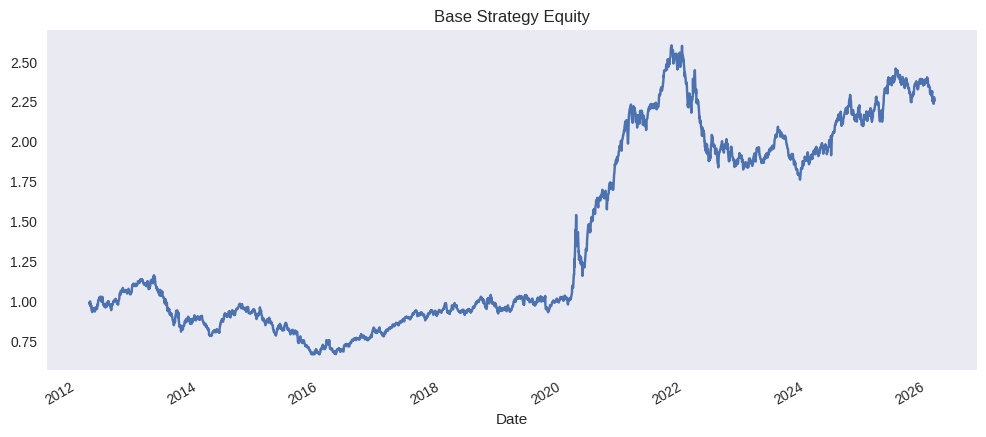

In [43]:
df["StratRet"] = df["BaseSignal"].shift(1) * df["Return"]

df["Equity"] = (1 + df["StratRet"]).cumprod()


df["Equity"].plot(figsize=(12,5),
                  title="Base Strategy Equity")

plt.grid()
plt.show()



In [44]:
def triple_barrier_param(df, tp, sl, max_holding=10):

    labels = []

    prices = df["Close"].squeeze().values
    signals = df["BaseSignal"].values


    for i in range(len(df)-max_holding):

        sig = signals[i]

        if sig == 0:
            labels.append(np.nan)
            continue


        entry = prices[i]
        outcome = 0


        for j in range(1, max_holding+1):

            ret = (prices[i+j] - entry)/entry * sig


            if ret >= tp:
                outcome = 1
                break

            if ret <= -sl:
                outcome = 0
                break


        labels.append(outcome)


    labels += [np.nan]*max_holding

    return pd.Series(labels, index=df.index)




In [45]:
def walk_forward_meta(data, features,
                      train_size=800,
                      step=100):

    equity = 1.0
    equity_curve = []


    for start in range(0,
                       len(data)-train_size-step,
                       step):

        train = data.iloc[start:start+train_size]
        test  = data.iloc[start+train_size:
                          start+train_size+step]


        train = train.dropna()
        test = test.dropna()


        if len(train) < 200 or len(test) < 20:
            continue


        X_train = train[features]
        y_train = train["MetaLabel"]

        X_test = test[features]


        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)


        model = RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            random_state=42
        )

        model.fit(X_train, y_train)


        pred = model.predict(X_test)


        final_sig = (
            test["BaseSignal"].values * pred
        )


        rets = (
            final_sig[:-1] *
            test["Return"].values[1:]
        )


        for r in rets:

            equity *= (1+r)
            equity_curve.append(equity)


    return pd.Series(equity_curve)



In [46]:
features = [
    "Return","Vol","RSI","MACD","MA_Diff"
]


tp_vals = [0.01,0.02,0.03]
sl_vals = [0.005,0.01,0.015]

results = []


for tp in tp_vals:
    for sl in sl_vals:

        temp = df.copy()

        temp["MetaLabel"] = triple_barrier_param(
            temp, tp, sl
        )

        temp = temp.dropna()


        wf = walk_forward_meta(
            temp, features
        )


        if len(wf) < 50:
            continue


        rets = wf.pct_change().dropna()


        sharpe = (
            np.sqrt(252) *
            rets.mean() /
            rets.std()
        )

        dd = (
            wf/wf.cummax()-1
        ).min()


        results.append({
            "TP":tp,
            "SL":sl,
            "Sharpe":round(sharpe,2),
            "DD":round(dd*100,2)
        })


pd.DataFrame(results)\
  .sort_values("Sharpe",ascending=False)



,TP,SL,Sharpe,DD
2,0.01,0.015,0.90,-28.36
0,0.01,0.005,0.79,-18.62
5,0.02,0.015,0.78,-13.82
3,0.02,0.005,0.71,-8.30
1,0.01,0.010,0.68,-24.89
4,0.02,0.010,0.66,-11.37
6,0.03,0.005,0.66,-7.92
7,0.03,0.010,0.61,-6.00
8,0.03,0.015,0.40,-10.62


In [47]:
best_tp = 0.02   # replace
best_sl = 0.01   # replace


df["MetaLabel"] = triple_barrier_param(
    df,best_tp,best_sl
)

data = df.dropna()



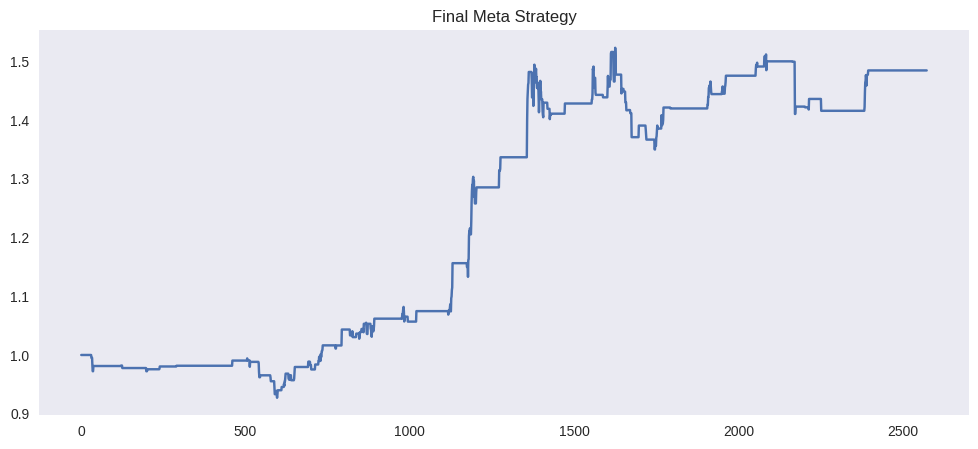

In [48]:
wf_final = walk_forward_meta(
    data,features
)


wf_final.plot(figsize=(12,5),
              title="Final Meta Strategy")

plt.grid()
plt.show()


In [49]:
rets = wf_final.pct_change().dropna()


sharpe = np.sqrt(252)*rets.mean()/rets.std()

dd = (
    wf_final/wf_final.cummax()-1
).min()


print("Final Sharpe:",round(sharpe,2))
print("Max DD:",round(dd*100,2),"%")



Final Sharpe: 0.66
Max DD: -11.37 %


META-LABELING SYSTEM — FINAL REPORT

BASE STRATEGY
Sharpe: 0.45
Max DD: -42.77 %

META STRATEGY (Walk-Forward)
Sharpe: 0.66
Max DD: -11.37 %


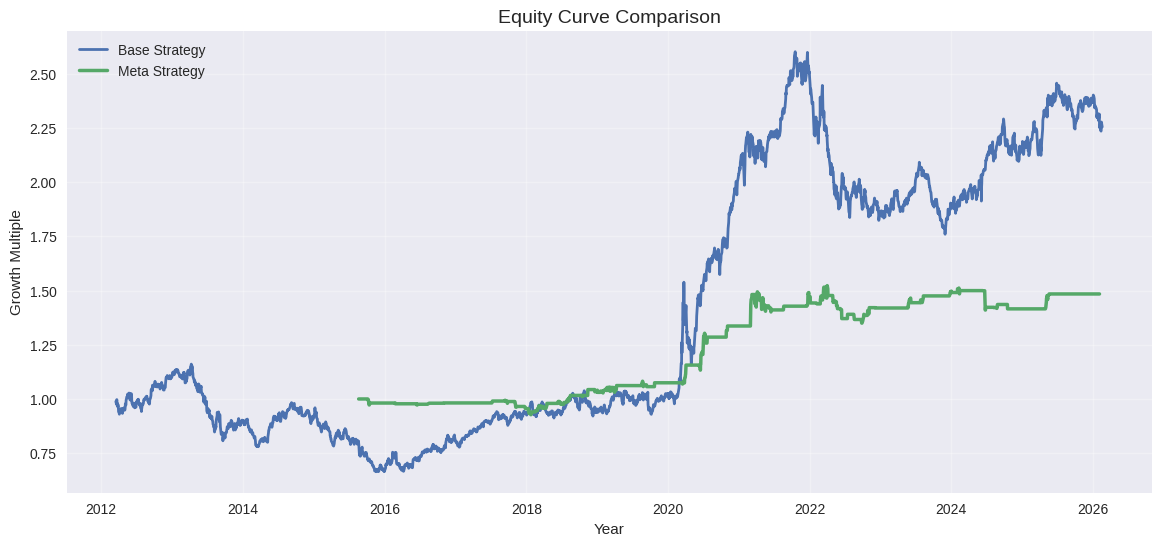

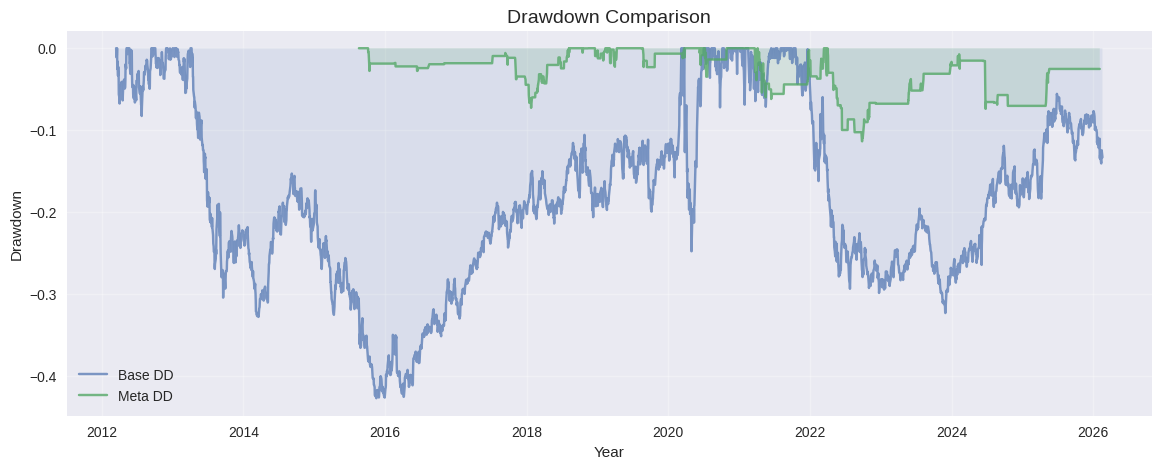

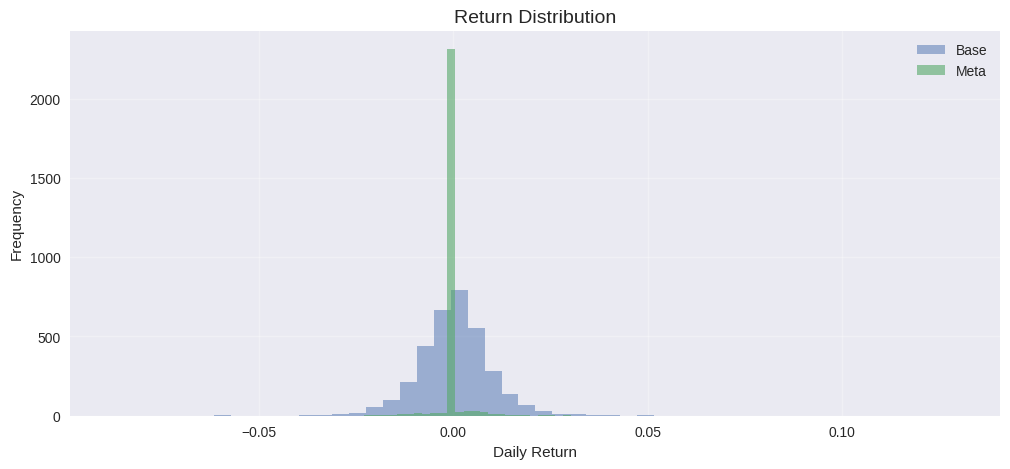

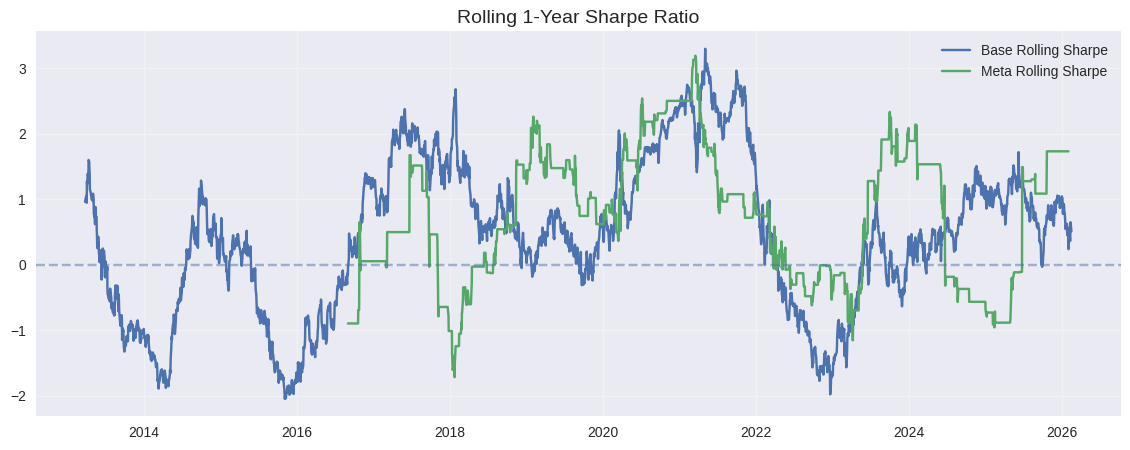


REPORT COMPLETE


In [51]:
# ============================================
# PROFESSIONAL FINAL VISUALIZATION CELL
# ============================================

print("="*60)
print("META-LABELING SYSTEM — FINAL REPORT")
print("="*60)


# --------------------------------------------
# ALIGN META EQUITY WITH DATES
# --------------------------------------------

meta_dates = data.index[-len(wf_final):]

meta_equity = pd.Series(
    wf_final.values,
    index=meta_dates
)


# --------------------------------------------
# METRICS
# --------------------------------------------

base_rets = df["StratRet"].dropna()
meta_rets = meta_equity.pct_change().dropna()


def sharpe(rets):
    return np.sqrt(252)*rets.mean()/rets.std()


def max_dd(equity):
    return (equity/equity.cummax()-1).min()


print("\nBASE STRATEGY")
print("Sharpe:", round(sharpe(base_rets),2))
print("Max DD:", round(max_dd(df["Equity"])*100,2),"%")

print("\nMETA STRATEGY (Walk-Forward)")
print("Sharpe:", round(sharpe(meta_rets),2))
print("Max DD:", round(max_dd(meta_equity)*100,2),"%")

print("="*60)


# ============================================
# GRAPH 1 — EQUITY CURVES
# ============================================

plt.figure(figsize=(14,6))

plt.plot(
    df["Equity"],
    label="Base Strategy",
    linewidth=2
)

plt.plot(
    meta_equity,
    label="Meta Strategy",
    linewidth=2.5
)

plt.title("Equity Curve Comparison", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Growth Multiple")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================
# GRAPH 2 — DRAWDOWN CURVES
# ============================================

base_dd = df["Equity"]/df["Equity"].cummax()-1
meta_dd = meta_equity/meta_equity.cummax()-1


plt.figure(figsize=(14,5))

plt.plot(base_dd, label="Base DD", alpha=0.7)
plt.plot(meta_dd, label="Meta DD", alpha=0.8)

plt.fill_between(
    base_dd.index,
    base_dd,
    0,
    alpha=0.1
)

plt.fill_between(
    meta_dd.index,
    meta_dd,
    0,
    alpha=0.15
)


plt.title("Drawdown Comparison", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================
# GRAPH 3 — RETURN DISTRIBUTION
# ============================================

plt.figure(figsize=(12,5))

plt.hist(
    base_rets,
    bins=50,
    alpha=0.5,
    label="Base"
)

plt.hist(
    meta_rets,
    bins=50,
    alpha=0.6,
    label="Meta"
)


plt.title("Return Distribution", fontsize=14)
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================
# GRAPH 4 — ROLLING SHARPE
# ============================================

rolling = 252

base_roll = (
    base_rets.rolling(rolling).mean() /
    base_rets.rolling(rolling).std()
) * np.sqrt(252)

meta_roll = (
    meta_rets.rolling(rolling).mean() /
    meta_rets.rolling(rolling).std()
) * np.sqrt(252)


plt.figure(figsize=(14,5))

plt.plot(base_roll, label="Base Rolling Sharpe")
plt.plot(meta_roll, label="Meta Rolling Sharpe")

plt.axhline(0, linestyle="--", alpha=0.5)

plt.title("Rolling 1-Year Sharpe Ratio", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)

plt.show()


print("\nREPORT COMPLETE")
print("="*60)

